## Puprose of Notebook ## 

Matching DES SNIa to host galaxies listed as part of the DR1 DESI data release. 

## Content of DESI Galaxy Metadata Files ##



Please note that in this notebook there are two .fits files:

- `desi_galaxy_metadata_dark.fits`
-  `desi_galaxy_metadata.fits`

These files were filtered out from the main raw data files found at: 

https://data.desi.lbl.gov/public/dr1/

What Each Collumn of raw .fits files means: https://fastspecfit.readthedocs.io/en/stable/fastspec.html


The filtering consisted of getting out only galaxy related information from agregate data 
that was part of both the dark and bright iron fits survey.

The original desi data contained Qasuars Stars and Galaxies. The filtering work done here 
involved only looking at the Galaxy data and taking out the following parameters:

['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']

For the work on how this was done please refer to:

`DES5YR_DESI_explore.ipynb`

## More detials on how data was sourced: ##

The reference for the following description is the following paper: https://arxiv.org/abs/2503.14745

Within each survey, objects are observed in one of three possible programs, depending on the acceptable lunar phase and on-sky observing conditions:

- **bright** — Observed during bright time (e.g., near full Moon)
- **dark** — Observed during dark time (e.g., new Moon)
- **backup** — Observed when conditions are not ideal for primary programs

I chose to focus only on the bright and dark survey. This is where the two data files end up coming from. Backup data set was ignored b/c it contained secondary and tertiary targets.

### Spectroscopic Production in DESI DR1 - IRON

Spectroscopic production: full, systematic data processing pipeline run on a defined set of raw DESI spectroscopic exposures. Each production results in calibrated spectra, redshifts, and other derived quantities that are released for public use and scientific analysis.

The primary spectroscopic production for DR1 is called **Iron**, named after the Iron Mountain in Utah. This production includes data from the first 13 months of the DESI main survey, as well as a uniform reprocessing of the Science Validation (SV) data that was previously part of the Early Data Release (EDR). 

In addition to Iron, DR1 also includes a supplemental production called **Guadalupe** (named after the Guadalupe Mountains in Texas), which contains data from just the first two months of the main survey. Although Guadalupe was used in early DESI analyses, it was processed using the same calibration and software as the older Fuji production used in the EDR. As such, Iron should be preferred over Guadalupe for any current or future work, due to its broader coverage and superior data processing quality.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

### Defining a function that converts RA/DEC from degrees to Mollweide-friendly radians ###

This is done because when we plot a molleweide projection later the function responsible for it only takes in radians as arguments.

Note: this is pretty counter-intuitive because the function is after all: displaying our output in degrees 🤣.


In [9]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

### Making a Plot of DES5YR SNIa host galaxy locations vs. the bright and dark galaxies from DESI ###

Turns out that some of the SNIa that were part of the DES5YR data release were missing their host galaxy coordiantes. 
So what is plotted here is only the SNIa Host Galaxy coordiantes that existed. It is also worth it to note that in this case these were only the SNIa
that were part of the DES data release.

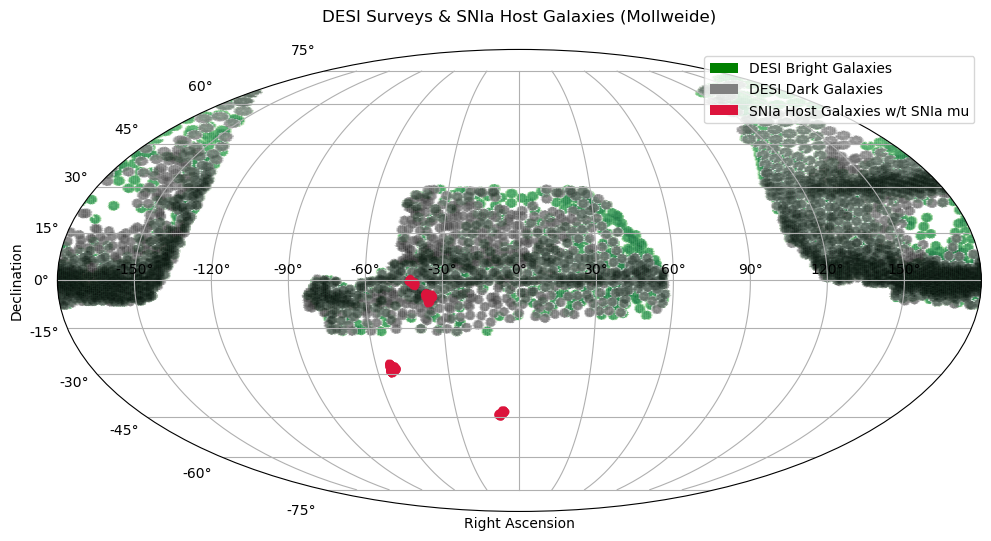

In [6]:
# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['HOST_RA'] != -999) & (sn_df['HOST_DEC'] != -999)
host_ra = sn_df.loc[valid_hosts, 'HOST_RA'].values
host_dec = sn_df.loc[valid_hosts, 'HOST_DEC'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1)
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

### Plotting A Superposition of SNIa that have Host Galaxy Information and those that Don't ###

We first start by creating and saving a .csv of all the entries where the host galaxy locations were missing. 
Note: just because the location is missing, doesn't mean that the host galaxy does not exist for the SNIa. 
It's just been forgotten/or maybe there was an error in getting this hostgalaxy information out there. 


In [12]:
# Load the metadata CSV
df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter for invalid host galaxy coordinates (i.e., -999)
bad_host_mask = (df['HOST_RA'] == -999) | (df['HOST_DEC'] == -999)
bad_hosts = df[bad_host_mask]

# Save to a new CSV
bad_hosts.to_csv("snia_with_missing_host_coords.csv", index=False)

print(f"Saved {len(bad_hosts)} SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv")

Saved 194 SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv


In this instance the SNIa that have host galaxy coordiantes associated with them will be in red.

The SNIa that don't have host galaxy coordiantes associated with them will be in yellow. Note: that for these coordiantes: we will only use the SNIa coordiantes
b/c the host galaxy coordinates are missing. 

In [14]:
# === Load SNIa Partial Match CSV ===
partial_df = pd.read_csv("snia_with_missing_host_coords.csv")
valid_partial = partial_df['RA'].notna() & partial_df['DEC'].notna()
partial_ra = partial_df.loc[valid_partial, 'RA'].values
partial_dec = partial_df.loc[valid_partial, 'DEC'].values
x_partial, y_partial = prepare_coords(partial_ra, partial_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# DESI Bright (density)
ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
          mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
          mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts with mu (scatter)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# SNIa from match CSV (scatter, fixed orange color)
ax.scatter(x_partial, y_partial, s=15, color='orange', alpha=1, label='SNIa Partial Matches')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1),
    Patch(facecolor='orange', label='SNIa Missing Host Galaxy Information', alpha=1)
]

# External legend
ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.,
    frameon=True
)

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'RA'

# Creating a CSV with Just the SNIa missing the Host Galaxy infromation #

In [1]:
import pandas as pd

# Load the metadata CSV
df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter for invalid host galaxy coordinates (i.e., -999)
bad_host_mask = (df['HOST_RA'] == -999) | (df['HOST_DEC'] == -999)
bad_hosts = df[bad_host_mask]

# Save to a new CSV
bad_hosts.to_csv("snia_with_missing_host_coords.csv", index=False)

print(f"Saved {len(bad_hosts)} SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv")

Saved 194 SNe Ia with invalid host coordinates to snia_with_bad_hosts.csv


# The .csv file containing Metadata Not only Has Missing Host Galaxy location information but is also missing the SNIa Locaiton #

Lets see if all the missing analysis data came form the LOW-Z data-set 

In [3]:
from astropy.io import fits
import pandas as pd

# Path to your file
fits_path = "/global/homes/m/myc21/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"

# Open the FITS file
with fits.open(fits_path) as hdul:
    print("\n=== HDU 0 (PRIMARY) ===")
    print(f"Type: {type(hdul[0])}")
    print("Header:")
    print(repr(hdul[0].header))
    print("Data:")
    print(hdul[0].data)  # Should be None or empty

    print("\n=== HDU 1 (Binary Table) ===")
    data = hdul[1].data
    print(f"Number of rows: {len(data)}")
    print("Column names:")
    print(data.columns.names)
    print("\nFirst 3 rows:")
    print(data[:3])


=== HDU 0 (PRIMARY) ===
Type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>
Header:
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    1 / number of data axes                            
NAXIS1  =                    0 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
HIERARCH CODE_IVERSION =    24 / Internal SNFTSIO code version                  
HIERARCH SNANA_PATH = '        ' / SNANA code directory                         
HIERARCH SNANA_VERSION = 'v11_05n-89-g9b3758e' / SNANA version                  
SURVEY  = 'DES5YR_LOWZ_COMBINED' / Survey                                       
HIERARCH SUBSURVEY_FLAG

In [7]:
from astropy.io import fits

# Path to your HEAD.FITS file
fits_path = "/global/homes/m/myc21/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"

# Open the FITS file and extract SNIDs
with fits.open(fits_path) as hdul:
    header_table = hdul[1].data  # HDU 1 is the binary table
    snids = header_table['SNID']

# Print SNIDs
print("List of SNIDs:")
for snid in snids:
    print(snid)

print(len(snids))
      

List of SNIDs:
2004ef
2005am
2005el
2005eq
2005hc
2005hj
2005hk
2005iq
2005ir
2005kc
2005ke
2005ki
2005lu
2005mc
2005M
2005na
2006ax
2006bd
2006br
2006bt
2006D
2006ef
2006ej
2006et
2006ev
2006gj
2006gt
2006hb
2006is
2006kf
2006ob
2006os
2006ot
2006X
2007af
2007ai
2007al
2007ax
2007ba
2007bc
2007bd
2007bm
2007ca
2007cg
2007N
2007S
2007sr
2008bf
2007A
2007hj
2007if
2007le
2007nq
2007ux
2008ae
2008ar
2008bi
2008bz
2008C
2008cd
2008cf
2008fr
2008gl
2008hj
2008hv
2009ad
2009al
2009dc
2009D
2009ds
2009Y
2009le
2008J
2007jd
2006hx
2008gp
2004gc
2006mr
2006bh
2009aa
2007ol
2007on
2008hu
2007st
2007as
2008ff
2005W
2005bg
2007mm
2010ae
2006fw
2008ia
2004eo
2005al
2005bl
2008fp
2005ku
2009J
2008bc
2009F
2006lu
2009I
2006dd
2005be
2008O
2007so
2008fl
2005gj
2005ag
2008fw
2005bo
2007hx
2005A
2008bt
2004ey
2008cc
2004gs
2008fu
2007jg
2008bd
2009P
2008bq
2006py
2008gg
2007jh
2008ha
2008go
2009ab
2008R
2009ag
2006eq
2004dt
2004gu
2009cz
iPTF13ebh
2011iv
2007co
2005ms
2007qe
2006ac
2007ae
2005ew
2006ke

In [17]:
import pandas as pd
from astropy.io import fits

# --- Step 1: Load the metadata CSV ---
csv_path = "DES5YR_DESI_match_data/snia_with_missing_host_coords.csv"
meta_df = pd.read_csv(csv_path)
print(meta_df.columns)
print("Length of SNIa with Missing HostGal Info: " + str(len(meta_df)))

# --- Step 2: Load the FITS header file ---
fits_path = "DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"
with fits.open(fits_path) as hdul:
    header_data = hdul[1].data
    fits_df = pd.DataFrame(header_data.byteswap().newbyteorder())
print(fits_df.columns)

merged_df = pd.merge(meta_df, fits_df[['SNID', 'RA', 'DEC']], on='SNID', how='left')

# --- Step 4: Save the merged file ---
merged_df.to_csv("DES-SN5YR_HD+MetaData_with_coords.csv", index=False)
print("✅ Saved: DES-SN5YR_HD+MetaData_with_coords.csv")

Index(['SNID', 'CIDint', 'IDSURVEY', 'TYPE', 'zHEL', 'zHELERR', 'zCMB',
       'zCMBERR', 'zHD', 'zHDERR', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_ZSPEC',
       'HOST_ZSPECERR', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'HOST_DDLR',
       'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'HOST_COLOR', 'HOST_COLOR_ERR',
       'PKMJD', 'PKMJDERR', 'x1', 'x1ERR', 'c', 'cERR', 'mB', 'mBERR',
       'mB_corr', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'NDOF',
       'FITPROB', 'PROB_SCONE', 'PROB_SNIRFV19', 'PROB_SNNDESCC',
       'PROB_SNNJ17', 'PROB_SNNV19', 'MU', 'MUERR_FINAL', 'PROBCC_BEAMS',
       'biasCor_mu', 'biasCor_muCOVSCALE', 'biasCor_muCOVADD'],
      dtype='object')
Length of SNIa with Missing HostGal Info: 195
Index(['SUBSURVEY', 'SNID', 'IAUC', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC',
       'PIXSIZE', 'NXPIX', 'NYPIX',
       ...
       'HOSTGAL_SB_FLUXCAL_D', 'HOSTGAL_SB_FLUXCAL_E', 'HOSTGAL_SB_FLUXCAL_F',
       'HOSTGAL_SB_FLUXCAL_G', 'HOSTGAL_SB_FLUXCAL_H', 'PEAKMJD',
       'M

# lets Just Look at Astroquery #

In [25]:
from astroquery.ipac.ned import Ned
import numpy as np

# Set numpy print options for full display
np.set_printoptions(threshold=np.inf, linewidth=1000)

# Query
sn_name = "2008050"
result_table = Ned.query_object(sn_name)

# Print full table
print(result_table)

# Also print column names and values explicitly
print("\n--- Full Column Breakdown ---")
for col in result_table.colnames:
    print(f"{col}: {result_table[col][0]}")

RemoteServiceError: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.

In [20]:
Ned.query_object()

TypeError: NedClass.query_object() missing 1 required positional argument: 'object_name'

# Take the table with SNID's and replace the SNID Collumn with "SN" + SNID for propper input in astroquery #

In [4]:
import pandas as pd

# Load the CSV
df = pd.read_csv("DES5YR_DESI_match_data/snia_with_missing_host_coords.csv")

# Prepend "SN" to each SNID
df["SNID"] = "SN" + df["SNID"].astype(str)

# Save it back
df.to_csv("DES5YR_DESI_match_data/snia_with_missing_host_coords_snid_4_astroquery.csv", index=False)

# Check how many of the Modified SNIDS return anything useful from Astroquery #

In [8]:
import pandas as pd
from astroquery.simbad import Simbad
import time

# Load the CSV with preformatted SNIDs
df = pd.read_csv("DES5YR_DESI_match_data/snia_with_missing_host_coords_snid_4_astroquery.csv")

# SIMBAD setup
simbad = Simbad()
simbad.TIMEOUT = 10

# Function to check if SIMBAD finds the object
def check_simbad(sn_name):
    try:
        return simbad.query_object(sn_name) is not None
    except:
        return False

# Build result list
results = []
for sn in df['SNID']:
    found = check_simbad(sn)
    results.append({'SN': sn, 'Found': found})
    time.sleep(0.5)  # polite delay

# Save the SN,Found table
out_df = pd.DataFrame(results)
out_df.to_csv("DES5YR_DESI_match_data/astroquery_found_table.csv", index=False)

print("✅ Done. Saved: astroquery_found_table.csv")
print(len(out_df))

✅ Done. Saved: astroquery_found_table.csv
195


# Copy the RA, DEC, and REDSHIFT of the SNIa to Astroquery  #

In [21]:
import pandas as pd
from astroquery.ipac.ned import Ned
import time

# Load your SN list
df = pd.read_csv("DES5YR_DESI_match_data/snia_with_missing_host_coords_snid_4_astroquery.csv")

# Initialize result columns
df["RA"] = None
df["DEC"] = None
df["Redshift"] = None

# Query NED and append results
for i, sn in enumerate(df["SNID"]):
    try:
        res = Ned.query_object(sn)
        df.at[i, "RA"] = res["RA"][0]
        df.at[i, "DEC"] = res["DEC"][0]
        df.at[i, "Redshift"] = res["Redshift"][0]
    except Exception as e:
        print(f"⚠️ Failed for {sn}: {e}")
    time.sleep(0.5)  # polite pause

# Save output
df.to_csv("DES5YR_DESI_match_data/snia_with_coords_and_redshift.csv", index=False)
print("✅ Done. Saved: snia_with_coords_and_redshift.csv")

⚠️ Failed for SN2008050: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.
⚠️ Failed for SN2008051: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.
⚠️ Failed for SNASASSN-15bc: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.
⚠️ Failed for SNASASSN-15fa: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.
⚠️ Failed for SNASASSN-15hg: The remote service returned the following error message.
ERROR: The object name that you have submitted is not currently recognized by the NED name interpreter.
⚠️ Failed for SNASASSN-15jl: The remote service returned t

# Ok you know WHAt LEts Go back tot he basics boo. Lets first just read in the CSV that has missing HOSTGAL coordiantes #

In [1]:
import pandas as pd

# Path to your CSV
csv_path = "/Users/pittsburghgraduatestudent/repos/first_paper/DES5YR_DESI_match_data/snia_with_missing_host_coords.csv"

# Load the file
df = pd.read_csv(csv_path)

# Show the first few SNIDs
print(df["SNID"].head())
print(f"✅ Loaded {len(df)} supernovae.")

0    2001ah
1    2001ay
2    2001az
3    2001eh
4    2002bf
Name: SNID, dtype: object
✅ Loaded 195 supernovae.


# Explore Foundation Data Set and Its SNIa coordiantes #

In [3]:
from astropy.io import fits
import pandas as pd

fits_path = "/Users/pittsburghgraduatestudent/repos/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz"

with fits.open(fits_path) as hdul:
    data = hdul[1].data
    print(data.columns.names)
    # Convert to native-endian NumPy structured array before using in pandas
    native_array = data.astype(data.dtype.newbyteorder('='))  
    df = pd.DataFrame(native_array)

# Now this should look reasonable
print(df[['RA', 'DEC']].head())

['SNID', 'IAUC', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'REDSHIFT_QUALITYFLAG', 'MASK_REDSHIFT_SOURCE', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_MAG_g', 'HOSTGAL_MAG_r', 'HOSTGAL_MAG_i', 'HOSTGAL_MAG_z', 'HOSTGAL_MAGERR_g', 'HOSTGAL_MAGERR_r', 'HOSTGAL_MAGERR_i', 'HOSTGAL_MAGERR_z', 'HOSTGAL2_OBJID', 'HOSTGAL2_FLAG', 'HOSTGAL2_PHOTOZ', 'HOSTGAL2_PHOTO

In [13]:
import pandas as pd
from astropy.io import fits

# Load CSV
csv_path = "DES5YR_DESI_match_data/snia_with_missing_host_coords.csv"
df_csv = pd.read_csv(csv_path)

# Load FITS
fits_path = "DES-SN5YR-1.2/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz"
with fits.open(fits_path) as hdul:
    data = hdul[1].data
    df_fits = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

# Create result list
matched_rows = []

matched_rows = []

for _, row_csv in df_csv.iterrows():
    short_snid = row_csv['SNID']
    idsurvey = row_csv['IDSURVEY']

    # Find match in FITS file
    matches = df_fits[df_fits['SNID'].astype(str).str.contains(str(short_snid), case=False)]

    if not matches.empty:
        row = matches.iloc[0]
        matched_rows.append({
            "SNID": short_snid,
            "IDSURVEY": idsurvey,
            "RA": row["RA"],
            "DEC": row["DEC"],
            "HOSTGAL_OBJID": row["HOSTGAL_OBJID"],
            "HOSTGAL_RA": row["HOSTGAL_RA"],
            "HOSTGAL_DEC": row["HOSTGAL_DEC"],
            "HOSTGAL_SPECZ": row["HOSTGAL_SPECZ"],
            "HOSTGAL_PHOTOZ": row["HOSTGAL_PHOTOZ"]
        })
    else:
        matched_rows.append({
            "SNID": short_snid,
            "IDSURVEY": idsurvey,
            "FULL_SNID": None,
            "RA": None,
            "DEC": None,
            "HOSTGAL_OBJID": None,
            "HOSTGAL_RA": None,
            "HOSTGAL_DEC": None,
            "HOSTGAL_SPECZ": None,
            "HOSTGAL_PHOTOZ": None
        })

# Convert to DataFrame and save
final_df = pd.DataFrame(matched_rows)
final_df.to_csv("snia_with_partial_match_host_coords.csv", index=False)
print("✅ Saved snia_with_partial_match_host_coords.csv")

✅ Saved snia_with_partial_match_host_coords.csv


# Note Reran the same code and lazily just copied and pasted data instead of being nice about it #

In [15]:
import pandas as pd
from astropy.io import fits

# Load CSV
csv_path = "/Users/pittsburghgraduatestudent/repos/first_paper/snia_with_partial_match_host_coords.csv"
df_csv = pd.read_csv(csv_path)

# Load FITS
fits_path = "/Users/pittsburghgraduatestudent/repos/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"
with fits.open(fits_path) as hdul:
    data = hdul[1].data
    df_fits = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

# Create result list
matched_rows = []

matched_rows = []

for _, row_csv in df_csv.iterrows():
    short_snid = row_csv['SNID']
    idsurvey = row_csv['IDSURVEY']

    # Find match in FITS file
    matches = df_fits[df_fits['SNID'].astype(str).str.contains(str(short_snid), case=False)]

    if not matches.empty:
        row = matches.iloc[0]
        matched_rows.append({
            "SNID": short_snid,
            "IDSURVEY": idsurvey,
            "RA": row["RA"],
            "DEC": row["DEC"],
            "HOSTGAL_OBJID": row["HOSTGAL_OBJID"],
            "HOSTGAL_RA": row["HOSTGAL_RA"],
            "HOSTGAL_DEC": row["HOSTGAL_DEC"],
            "HOSTGAL_SPECZ": row["HOSTGAL_SPECZ"],
            "HOSTGAL_PHOTOZ": row["HOSTGAL_PHOTOZ"]
        })
    else:
        matched_rows.append({
            "SNID": short_snid,
            "IDSURVEY": idsurvey,
            "FULL_SNID": None,
            "RA": None,
            "DEC": None,
            "HOSTGAL_OBJID": None,
            "HOSTGAL_RA": None,
            "HOSTGAL_DEC": None,
            "HOSTGAL_SPECZ": None,
            "HOSTGAL_PHOTOZ": None
        })

# Convert to DataFrame and save
final_df = pd.DataFrame(matched_rows)
final_df.to_csv("snia_with_partial_match_host_coords.csv", index=False)
print("✅ Saved snia_with_partial_match_host_coords.csv")

✅ Saved snia_with_partial_match_host_coords.csv


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

def load_redshift(path, label):
    data = Table.read(path)
    mask = (data['SPECTYPE'] == 'GALAXY') & (data['ZWARN'] == 0)
    return data['Z'][mask], label

# === Load Bright & Dark DESI Galaxies === #
z_bright, label_bright = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata.fits", "DESI Bright")
z_dark, label_dark = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits", "DESI Dark")

# === Load SNIa Host Galaxy Redshifts from CSV === #
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")  # replace path
z_host = sn_df.loc[sn_df['HOST_ZSPEC'] != -999, 'HOST_ZSPEC'].values
label_host = "DES SNIa w/t MU"

# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')
plt.hist(z_host, bins=bins, alpha=0.3, label=label_host, color='crimson', histtype='stepfilled')
plt.hist(z_total, bins=bins, alpha=1, label='Total Matched (Bright + Dark)', color='black', histtype='stepfilled')
print(len(z_total))


plt.title("Redshift Distribution: DESI Galaxies & DES SNIa Hosts")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Objects")
plt.legend(loc='upper right')
plt.yscale("log")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'DES5YR_DESI_match_data/desi_galaxy_metadata.fits'